# COLAB 1: Building Your First Research Workflow

## Course architecture

Data acquisition ➡️ Data analysis ➡️ Visualizing results ➡️ Documenting research

**Platform Context:** Google Colab Cloud VM (Standard CPU Runtime)  
**Motivating Domain:** Brain-Machine Interfaces & Neural Signal Analysis  
**Target Open Dataset:** Neural Voltage Signals (Extracellular Spiking Arrays)

## Instructions for the student
In this lab, you will act as a Workflow Designer building an integrated, automated research workflow for a single experimental subject.

Your objective is to pass the explicit **"AI Prompt Challenges"** directly to an AI coding assistant, evaluate the structural properties of the returned functions, and paste them into the designated code boundaries. Once your 4 stages are connected, you will use the Stage 5 Laboratory Playground at the bottom of the notebook to test your workflow under different analysis settings!

## Module 1: Data acquisition

As an example, we will work with a [dataset](https://www.kaggle.com/datasets/wajahat1064/emotion-recognition-using-eeg-and-computer-games?resource=download) that contains EEG signals recorded from participants playing emotionally different computer games (boring, calm, horror, funny). We will download and analyze data from participant S01.

#### Student AI prompt challenge

Copy and paste the code block from the cell below and the following text block into your AI assistant:

> "Write a function get_data(data_config) that takes the DATA_CONFIG below, reads each file with pandas using urls from the values, adds a game identifier to each file (the corresponding key), concatenates all dataframe into one and returns it."

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_CONFIG = {
    "boring": "https://github.com/cyneuro/CI-BioEng-Class/raw/refs/heads/main/emotion_recognition/data/S01G1AllChannels.csv",
    "calm": "https://github.com/cyneuro/CI-BioEng-Class/raw/refs/heads/main/emotion_recognition/data/S01G2AllChannels.csv",
    "horror": "https://github.com/cyneuro/CI-BioEng-Class/raw/refs/heads/main/emotion_recognition/data/S01G3AllChannels.csv",
    "funny": "https://github.com/cyneuro/CI-BioEng-Class/raw/refs/heads/main/emotion_recognition/data/S01G4AllChannels.csv"
}

In [19]:
import pandas as pd

def get_data(data_config):
    dataframes = []

    for game, url in data_config.items():
        df = pd.read_csv(url)
        df["game"] = game
        dataframes.append(df)

    return pd.concat(dataframes, ignore_index=True)

In [20]:
data = get_data(DATA_CONFIG)
print(data)

             AF3      AF4       F3        F4       F7        F8      FC5  \
0      -33.02050 -15.1846 -42.1795   1.68720  42.1793  -1.68720  -5.5436   
1      -28.62910 -20.0583 -42.5410 -10.46530  35.3100 -15.68600 -19.3110   
2      -21.84970 -10.9006 -32.0346  -2.36560  39.6993  -0.64483  -4.0523   
3      -25.11850 -10.9702 -32.7641  -3.42870  32.7378   4.69650  -8.6299   
4      -19.03160  -9.5886 -29.1108  -3.94590  35.3533   0.79929 -12.6914   
...          ...      ...      ...       ...      ...       ...      ...   
153003  -2.15360  11.5483  -5.8549  14.84380 -11.9038  -8.64200  -6.8537   
153004   0.86767  11.9398   1.2451   7.20450   2.9104   5.97650   7.6575   
153005   1.29770   3.5106   1.6524   0.02345  16.8358  19.71790  21.2981   
153006  -5.04680   1.8540  -6.6415  -2.38820   1.7256   4.43480   5.9202   
153007  -7.39510   9.6965   2.6748   8.60140 -10.3085  -5.35170  -3.4733   

           FC6       O1        O2        P7        P8        T7        T8  \
0      -3.

In [21]:
data = get_data(DATA_CONFIG)
data.head()

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,O1,O2,P7,P8,T7,T8,Unnamed: 14,game
0,-33.0205,-15.1846,-42.1795,1.6872,42.1793,-1.68720,-5.5436,-3.6154,25.7899,-9.88190,5.5436,7.47180,11.8101,17.1128,NaN,boring
1,-28.6291,-20.0583,-42.5410,-10.4653,35.3100,-15.68600,-19.3110,-2.4344,17.4933,3.24420,18.7081,5.09510,17.3683,3.0708,NaN,boring
2,-21.8497,-10.9006,-32.0346,-2.3656,39.6993,-0.64483,-4.0523,-1.0830,26.8081,-3.45840,8.1861,8.40480,15.1209,9.3940,NaN,boring
3,-25.1185,-10.9702,-32.7641,-3.4287,32.7378,4.69650,-8.6299,-1.7412,16.7637,-9.75860,1.1868,0.91086,4.3315,8.1073,NaN,boring
4,-19.0316,-9.5886,-29.1108,-3.9459,35.3533,0.79929,-12.6914,1.0144,13.1068,-0.73692,8.1054,-1.31300,8.1694,8.3442,NaN,boring


## Module 2: Data analysis

#### Student AI prompt challenge

Copy and paste the following text block into your AI assistant:

> "Assume the columns of my dataframe are recordings from individual electrodes (AF3 to T8), with the identifier saved in the "game" column. Write a function run_anova(data) that takes each electrode in the data separately (AF3 to T8) and runs a simple ANOVA between the games. Print out the composite significance results table."

In [22]:
# TODO: Your code here
from scipy.stats import f_oneway


def run_anova(data):
    results = []

    electrodes = [col for col in data.columns if col != "game"]

    for electrode in electrodes:
        groups = [
            group[electrode].dropna()
            for _, group in data.groupby("game")
        ]

        f_stat, p_value = f_oneway(*groups)

        results.append({
            "electrode": electrode,
            "F-statistic": f_stat,
            "p-value": p_value,
            "significant": p_value < 0.05
        })

    results_table = pd.DataFrame(results)

    print(results_table)

    return results_table

In [23]:
results = run_anova(data)

      electrode  F-statistic   p-value  significant
0           AF3     0.001111  0.999949        False
1           AF4     0.012042  0.998194        False
2            F3     0.040109  0.989291        False
3            F4     0.008768  0.998874        False
4            F7     0.006097  0.999346        False
5            F8     0.081791  0.969952        False
6           FC5     0.011744  0.998260        False
7           FC6     0.041308  0.988820        False
8            O1     0.012095  0.998181        False
9            O2     0.055138  0.982970        False
10           P7     0.077225  0.972321        False
11           P8     0.017965  0.996726        False
12           T7     0.037164  0.990423        False
13           T8     0.002724  0.999804        False
14  Unnamed: 14          NaN       NaN        False


/tmp/ipykernel_4710/4151280184.py:16: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = f_oneway(*groups)


In [24]:
anova_result = run_anova(data)

      electrode  F-statistic   p-value  significant
0           AF3     0.001111  0.999949        False
1           AF4     0.012042  0.998194        False
2            F3     0.040109  0.989291        False
3            F4     0.008768  0.998874        False
4            F7     0.006097  0.999346        False
5            F8     0.081791  0.969952        False
6           FC5     0.011744  0.998260        False
7           FC6     0.041308  0.988820        False
8            O1     0.012095  0.998181        False
9            O2     0.055138  0.982970        False
10           P7     0.077225  0.972321        False
11           P8     0.017965  0.996726        False
12           T7     0.037164  0.990423        False
13           T8     0.002724  0.999804        False
14  Unnamed: 14          NaN       NaN        False


/tmp/ipykernel_4710/4151280184.py:16: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = f_oneway(*groups)


## Module 3: Visualizing results

#### Student AI prompt challenge

Copy and paste the following text block into your AI assistant:

> "Now write a function plot_results() that takes a dataframe in this format and makes a seabron histogram showing averages and SEMs. It should also take the anova_result table from the previous step and indicate significance with stars and no significance with NS."

In [25]:
# TODO: Your code here
import seaborn as sns
import matplotlib.pyplot as plt

def plot_results(data, anova_result):
    # Get electrode columns
    electrodes = [col for col in data.columns if col != "game"]

    # Calculate mean and SEM for each game and electrode
    summary = []

    for electrode in electrodes:
        grouped = data.groupby("game")[electrode]

        means = grouped.mean()
        sems = grouped.sem()

        for game in means.index:
            summary.append({
                "game": game,
                "electrode": electrode,
                "mean": means[game],
                "sem": sems[game]
            })

    summary = pd.DataFrame(summary)

    # Add significance labels from ANOVA results
    def significance_label(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return "NS"

    anova_labels = anova_result.copy()
    anova_labels["significance"] = anova_labels["p-value"].apply(
        significance_label
    )

    # Create one plot containing all electrodes
    plt.figure(figsize=(18, 7))

    sns.barplot(
        data=summary,
        x="electrode",
        y="mean",
        hue="game",
        errorbar="se"
    )

    # Add ANOVA significance labels
    y_max = summary["mean"].max()

    for i, electrode in enumerate(electrodes):
        result = anova_labels[
            anova_labels["electrode"] == electrode
        ]

        if not result.empty:
            label = result["significance"].iloc[0]

            electrode_values = summary[
                summary["electrode"] == electrode
            ]

            max_value = (
                electrode_values["mean"] +
                electrode_values["sem"]
            ).max()

            plt.text(
                i,
                max_value + (abs(y_max) * 0.05),
                label,
                ha="center",
                fontweight="bold"
            )

    plt.xlabel("Electrode")
    plt.ylabel("Mean ± SEM")
    plt.title("Electrode Activity by Game")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

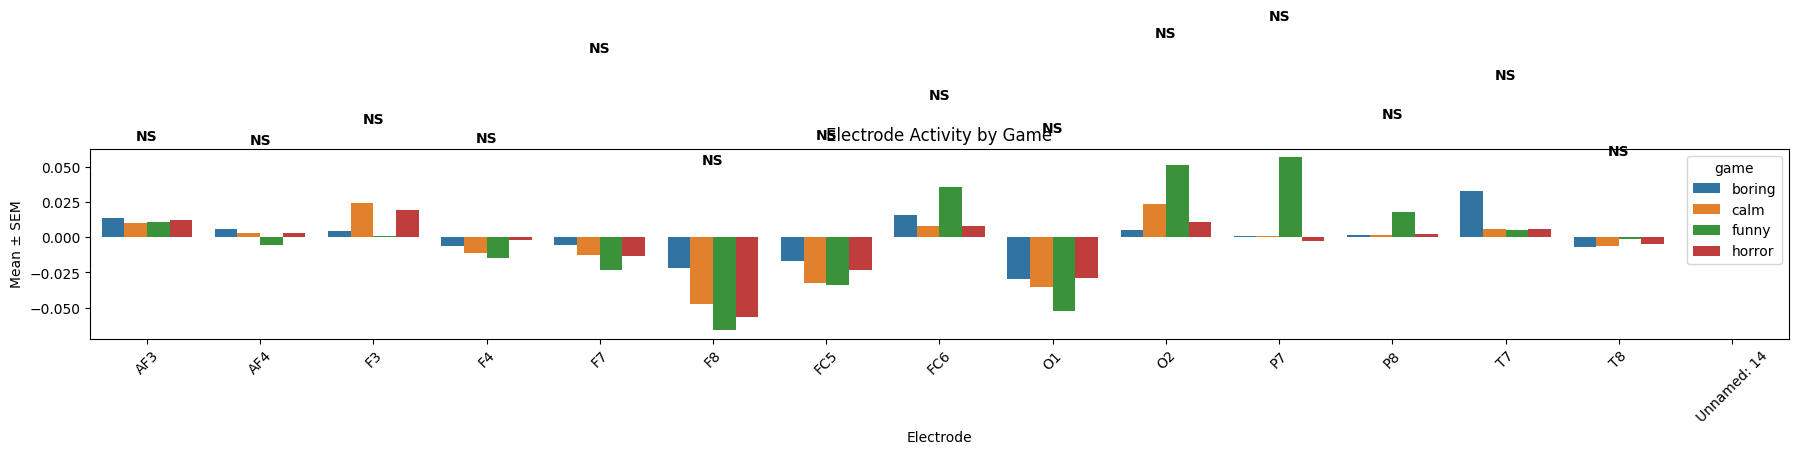

In [26]:
plot_results(data, results)

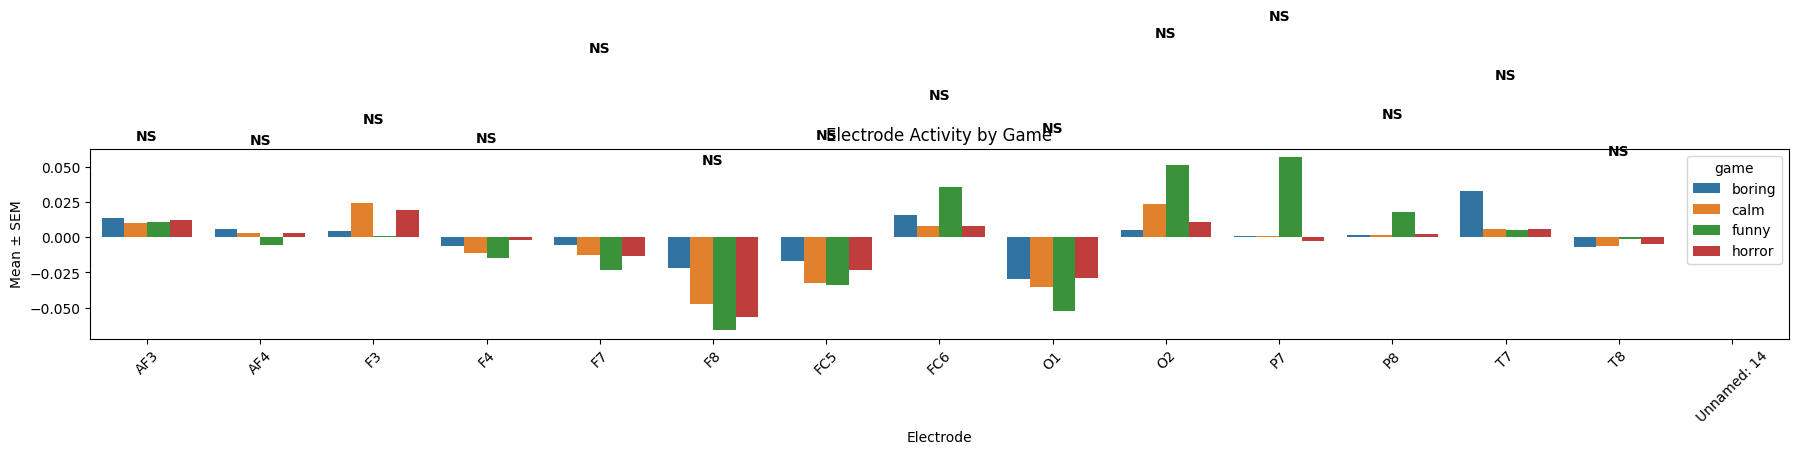

In [27]:
plot_results(data, anova_result)

## Module 4: Documenting research

#### Student AI prompt challenge

Copy and paste the code block from the cell below and the following text block into your AI assistant:

> "Assume the anova table from above is saved in the anova_result variable. Write a documentation logging function document_reserach that creates a pandas dataframe with the following columns: current date, number of singificant (p < 0.05) electrodes and returns it."

In [33]:
# TODO: Your code here
from datetime import date

def document_research(anova_result):
    significant_count = (anova_result["p-value"] < 0.05).sum()

    research_log = pd.DataFrame({
        "current date": [date.today()],
        "number of significant electrodes": [significant_count]
    })

    return research_log

In [34]:
research_log = document_research(anova_result)
print(research_log)

  current date  number of significant electrodes
0   2026-08-13                                 0


In [35]:
document_research(anova_result)

,current date,number of significant electrodes
0,2026-08-13,0


## Embedded playground

**Task 1.** Hypothesize which two game types could produce vastly different emotional responses and re-run the analyses only for these game types.

**Task 2.** Use AI to add basic preprocessing (re-referencing, filtering) to the workflow after obtaining the data and before running ANOVA. Does it affect the significance results?

/tmp/ipykernel_4710/4151280184.py:16: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = f_oneway(*groups)


      electrode  F-statistic   p-value  significant
0           AF3     0.001111  0.999949        False
1           AF4     0.012042  0.998194        False
2            F3     0.040109  0.989291        False
3            F4     0.008768  0.998874        False
4            F7     0.006097  0.999346        False
5            F8     0.081791  0.969952        False
6           FC5     0.011744  0.998260        False
7           FC6     0.041308  0.988820        False
8            O1     0.012095  0.998181        False
9            O2     0.055138  0.982970        False
10           P7     0.077225  0.972321        False
11           P8     0.017965  0.996726        False
12           T7     0.037164  0.990423        False
13           T8     0.002724  0.999804        False
14  Unnamed: 14          NaN       NaN        False


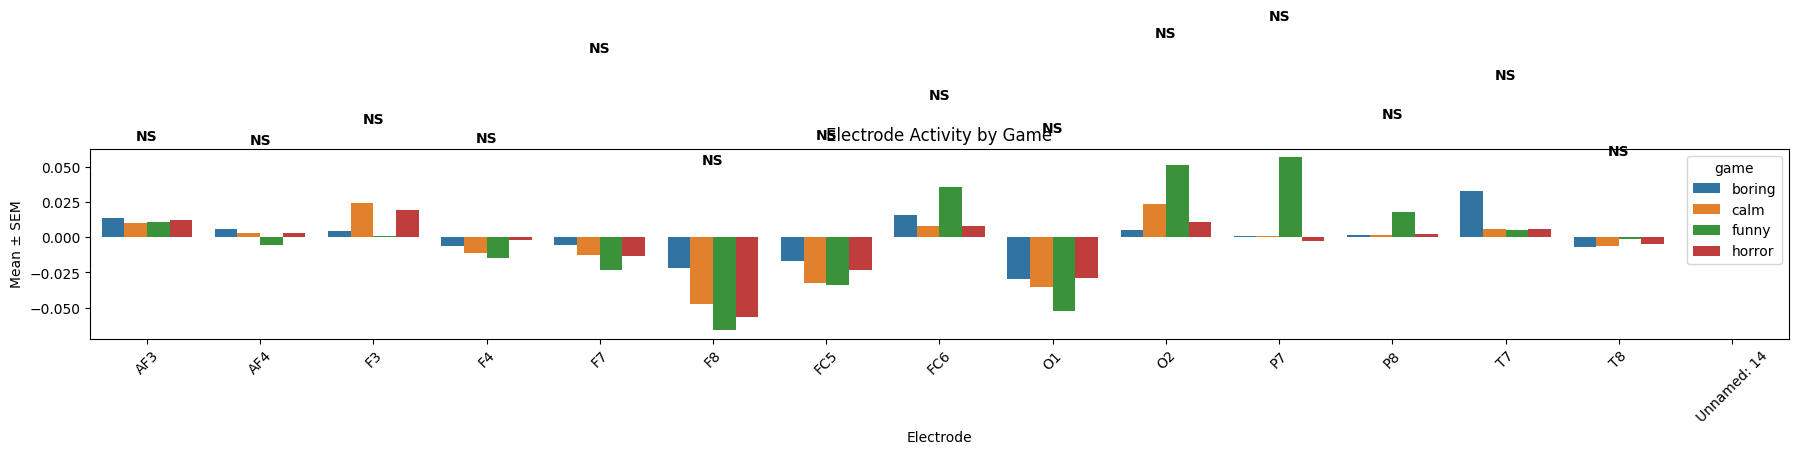

,current date,number of significant electrodes
0,2026-08-13,0


In [36]:
data = get_data(DATA_CONFIG)
anova_result = run_anova(data)
plot_results(data, anova_result)
document_research(anova_result)